# K-Means

<center>

__Modelación del Aprendizaje con Inteligencia Artificial__

_GPO 302_

Actividad 3 _Redes Neuronales (Keras)_


Prof. Jorge Adolfo Ramírez Uresti




Diego A. Parra Ruíz - - - A01801026
</center>

In [ ]:
pip install kneed

## Librerías

In [ ]:
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

## Creación de Blobs

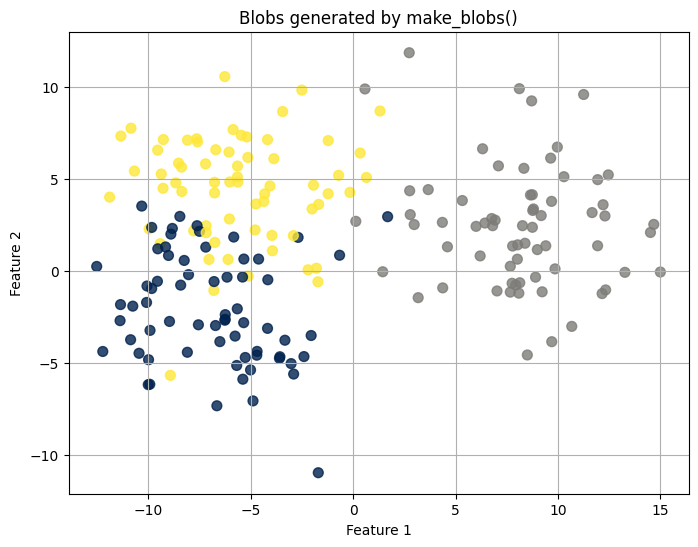

In [ ]:
features, true_labels = make_blobs(
n_samples = 200,
centers = 3,
cluster_std = 3
)
plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=true_labels, cmap='cividis', s=50, alpha=0.8)
plt.title("Blobs generated by make_blobs()")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
print(features[:5])
true_labels[:5]

[[ -3.96276823   1.92415283]
 [  0.57660014   9.88257839]
 [ -5.12395271  -0.286805  ]
 [ 11.9381327    4.95375966]
 [-10.86486182  -3.74664863]]


array([2, 1, 2, 1, 0])

## Escalamiento de Datos

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[-0.3355788 ,  0.08339766],
       [ 0.26965295,  2.03029406],
       [-0.49039896, -0.45747639],
       [ 1.78448051,  0.82454057],
       [-1.25583155, -1.30386957]])

## Activación de K-Means

In [ ]:
kmeans = KMeans(
init="random",
n_clusters=3,
n_init=10,
max_iter=300,
)

In [ ]:
kmeans.fit(scaled_features)

KMeans(init='random', n_clusters=3, n_init=10)

In [ ]:
# The lowest SSE value
print("Inertia: ", kmeans.inertia_)

# Final locations of the centroid
print("Cluster Center: ", kmeans.cluster_centers_)

# The number of iterations required to converge
print("Cycles: ", kmeans.n_iter_)

kmeans.labels_[:5]

Inertia:  118.4762379848949
Cluster Center:  [[-0.57292629  0.76932063]
 [ 1.30672978  0.14019087]
 [-0.69739164 -1.08265792]]
Cycles:  10


array([0, 0, 2, 1, 2], dtype=int32)

## Graficación del Modelo

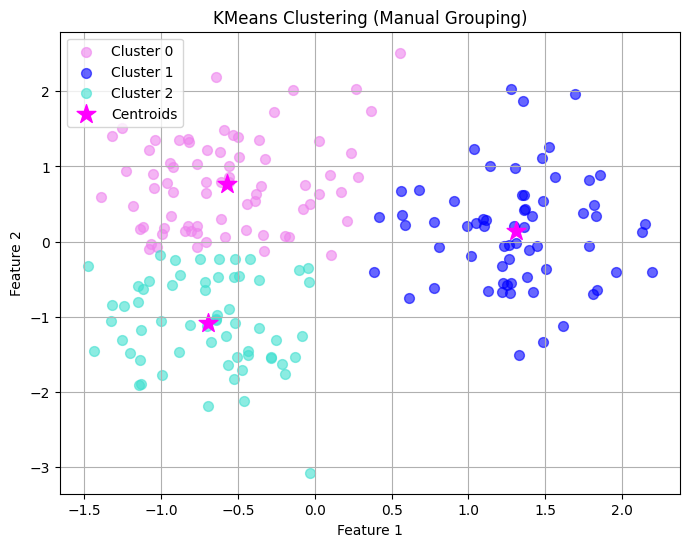

In [ ]:
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot each cluster separately
plt.figure(figsize=(8, 6))
colors = ['violet', 'blue', 'turquoise']

for i in range(3):
    cluster_points = scaled_features[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1],
                s=50, alpha=0.6, color=colors[i], label=f'Cluster {i}')

# Plot the centroids
plt.scatter(centers[:, 0], centers[:, 1],
            c='magenta', marker='*', s=200, label='Centroids') # Changed marker from 'scaled_features' to '*'

plt.title('KMeans Clustering (Manual Grouping)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

## Elbow Method Graph

In [ ]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 300,
    "random_state": 42,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

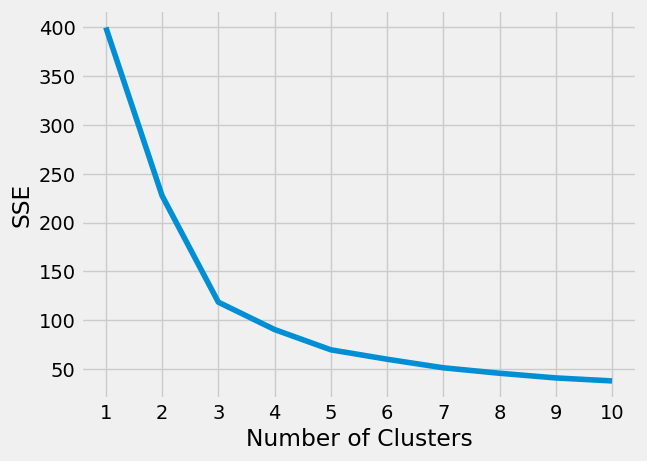

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
kl = KneeLocator(
    range(1, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

np.int64(3)

## Silhouette Method Graph

In [ ]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

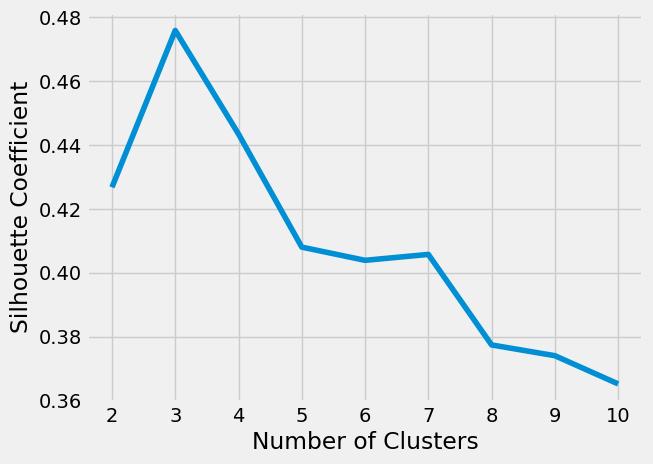

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

## Nuevo Modelo

### Creación de Blobs

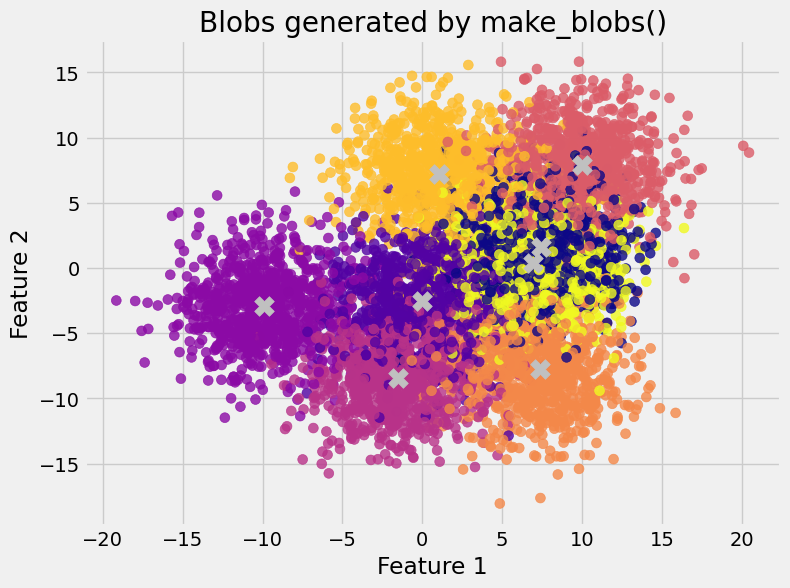

In [ ]:
features, true_labels, centers = make_blobs(
n_samples = 7000,
centers = 8,
return_centers=True,
cluster_std = 2.8
)


plt.figure(figsize=(8, 6))
plt.scatter(features[:, 0], features[:, 1], c=true_labels, cmap='plasma', s=50, alpha=0.8)

# Plot true centroids
plt.scatter(centers[:, 0], centers[:, 1],
            c='silver', marker='X', s=200, label='True Centers')

plt.title("Blobs generated by make_blobs()")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[:5]

array([[ 1.06856873,  0.22012477],
       [-0.35098429,  1.56852962],
       [ 1.20476779, -0.39986212],
       [-0.33719519, -0.70268012],
       [-0.50441886, -0.71403441]])

### Activación de K-Means

In [ ]:
kmeans = KMeans(
init="random",
n_clusters=8,
n_init=10,
max_iter=400,
)
kmeans.fit(scaled_features)

KMeans(init='random', max_iter=400, n_init=10)

In [ ]:
# The lowest SSE value
print("Inertia: ", kmeans.inertia_)

# Final locations of the centroid
print("Cluster Center: ", kmeans.cluster_centers_)

# The number of iterations required to converge
print("Cycles: ", kmeans.n_iter_)

kmeans.labels_[:5]

Inertia:  1747.766639360608
Cluster Center:  [[ 6.97425308e-01 -1.20697271e+00]
 [-1.87940244e+00 -3.67226071e-01]
 [-3.44398893e-01 -2.56489318e-01]
 [ 4.15246622e-01  5.76015488e-01]
 [-6.65341762e-01 -1.30601559e+00]
 [-3.28752283e-01  1.30799727e+00]
 [ 1.11742793e+00  1.37538958e+00]
 [ 9.01214356e-01  1.64466633e-03]]
Cycles:  26


array([7, 5, 7, 2, 2], dtype=int32)

### Graph de K-Means

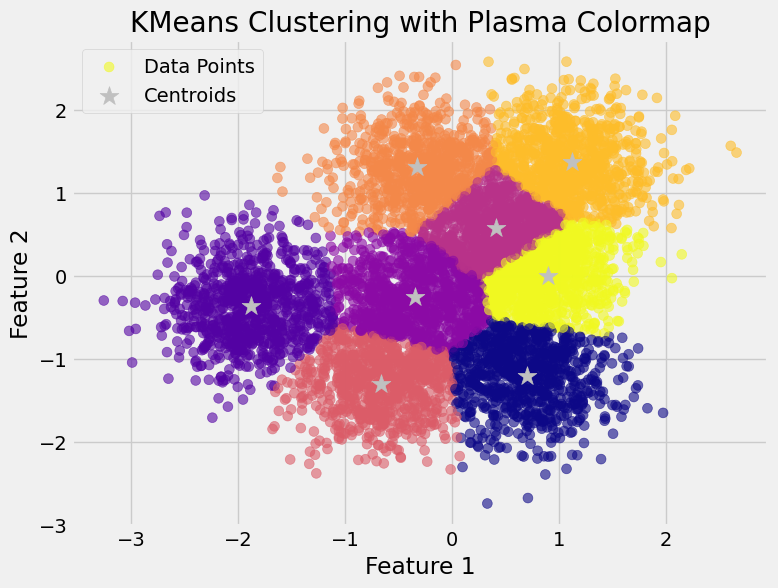

In [ ]:
labels = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

# Use c=labels and cmap='plasma' for automatic coloring
plt.scatter(scaled_features[:, 0], scaled_features[:, 1],
            c=labels, cmap='plasma', s=50, alpha=0.6, label='Data Points')

# Plot centroids
plt.scatter(centers[:, 0], centers[:, 1],
            c='silver', marker='*', s=200, label='Centroids')

plt.title('KMeans Clustering with Plasma Colormap')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

### Elbow Method Graph

In [ ]:
kmeans_kwargs = {
    "init": "random",
    "n_init": 10,
    "max_iter": 400,
}

# A list holds the SSE values for each k
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    sse.append(kmeans.inertia_)

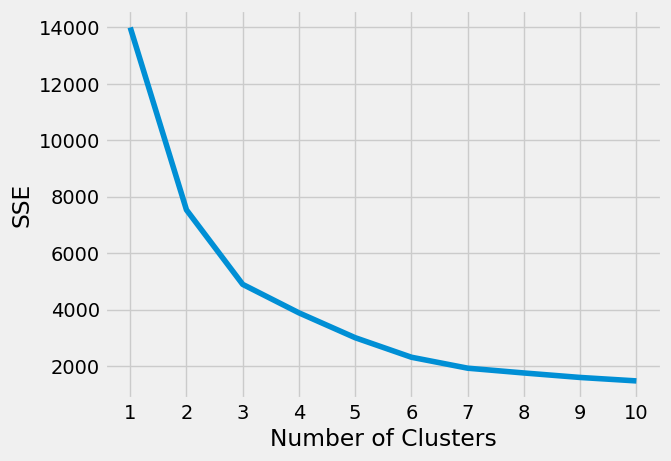

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [ ]:
kl = KneeLocator(
    range(1, 11), sse, curve="convex", direction="decreasing"
)

kl.elbow

np.int64(3)

### Silhouette Method Graph

In [ ]:
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
    kmeans.fit(scaled_features)
    score = silhouette_score(scaled_features, kmeans.labels_)
    silhouette_coefficients.append(score)

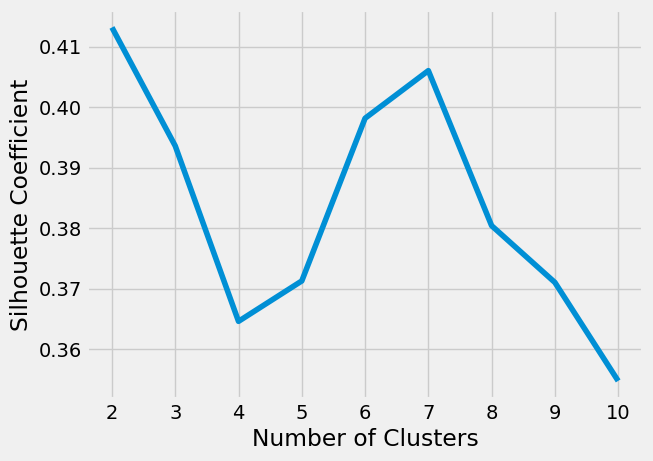

In [ ]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

### Mejor K para nuevo Dataset

Si bien ambos el método del codo y el método de la silueta arrojaron resultados diferentes, es posible observar algunas similitudes, por ejemplo, en el caso del método del codo se arrojó que el mejor K es K = 3, que al ser observado en el método de la silueta es posible apreciar que el K = 3 cuenta con un valor alto y relativamente confiable de silueta.

Sin embargo, como fue observado, el cálculo del método del codo depende únicamente de la inercia, del sistema, mientras que el método de la silueta cuenta con un sistema más robusto de clasificación para la proximidad y desproximidad en para cada punto con respecto a sus respectivos clusters de clasificación, por lo que se aceptará ek K = 3 como una cantidad decente de clusters, pero se le tratará como un máximo local, pues en este caso se observa en el método de la silueta que el mejor índice de K disponible para maximizar la efectividad de los clusters de este modelo es K = 7.

Una K bastante coherente dado que se eligió un K = 8 para la creación de blobs, por lo que un K = 7 --- 8 es una estimación muy efectiva de la mejor cantidad de blobsa para maximizar la efectividad del conjunto.

Ergo, se elije el método del codo y su K = 7 --- 8.